<a href="https://colab.research.google.com/github/BRakesha/ipl-data-analysis-python/blob/main/ipl_analysis_sns.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
ipl=pd.read_csv('/content/ipl_cleaned1.csv')
ipl.drop(columns='Unnamed: 0',inplace=True)

## 1. Which Teams Are Least Dependent on Toss Wins?

## level 0 = first index (season)
## level 1 = second index (winner)

In [ ]:
data=ipl[ipl['toss_winner']!=ipl['winner']].groupby(['season','winner']).size().groupby(level=0)
winner=data.idxmax()
winner=winner.apply(lambda row:row[1])
wins=data.max()
overall=pd.concat((winner,wins),axis=1)
overall.columns=['winner','wins']

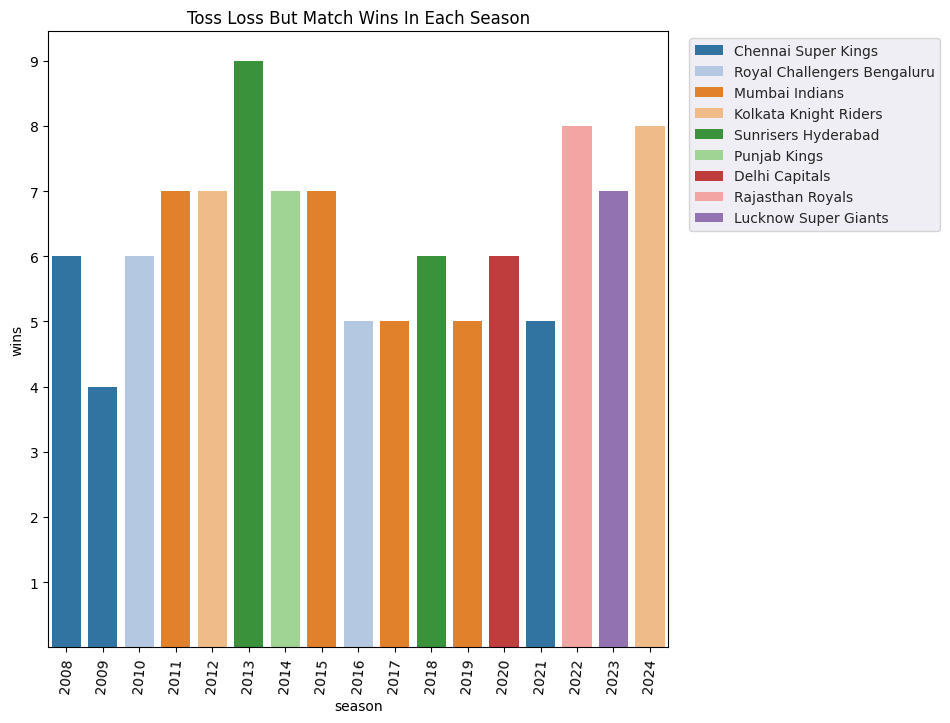

In [ ]:
plt.figure(figsize=(8,10))
sns.barplot(data=overall,x=overall.index,y='wins',hue='winner',palette='tab20')
plt.title("Toss Loss But Match Wins In Each Season")
sns.set_style('darkgrid')
plt.yticks(np.arange(1,overall['wins'].max()+1))
plt.xticks(rotation=85)
plt.legend(loc='upper right',bbox_to_anchor=(1.45,1))
plt.show()

## Find teams uncomfortable while chasing

/tmp/ipykernel_749/2911028936.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


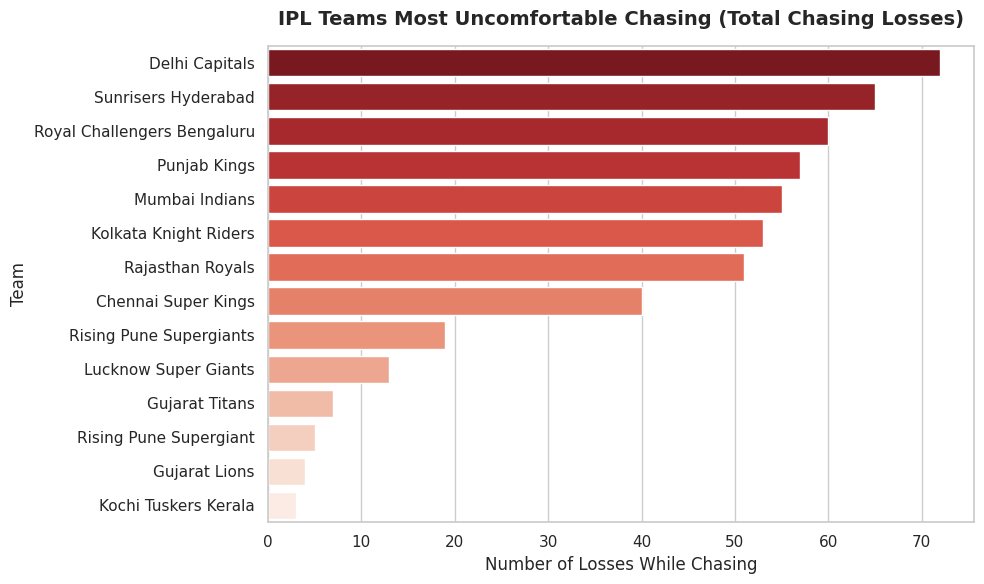

In [ ]:
field_win = ipl[
    (ipl['toss_decision'] == 'field') &
    (ipl['toss_winner'] != ipl['winner'])
]['toss_winner']

bat_win = ipl[
    (ipl['toss_decision'] == 'bat') &
    (ipl['toss_winner'] == ipl['winner'])
].apply(
    lambda row: row['team1'] if row['toss_winner'] == row['team2'] else row['team2'],
    axis=1
).reset_index(drop=True)

chasing_loss = pd.concat((field_win, bat_win)).value_counts()
df_plot = chasing_loss.reset_index()
df_plot.columns = ['Team', 'Chasing_Losses']

df_plot = df_plot.sort_values(by='Chasing_Losses', ascending=False)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

sns.barplot(
    x='Chasing_Losses',
    y='Team',
    data=df_plot,
    palette='Reds_r'
)

plt.title('IPL Teams Most Uncomfortable Chasing (Total Chasing Losses)', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Number of Losses While Chasing', fontsize=12)
plt.ylabel('Team', fontsize=12)

plt.tight_layout()
plt.show()

## Pressure-handling analysis.

In [ ]:
byrun=ipl[(ipl['result']=='runs') & (ipl['result_margin']<=10)]
bywicket=ipl[(ipl['result']=='wickets') & (ipl['result_margin']<=2)]
pressure=pd.concat((byrun,bywicket)).groupby(['season','winner']).size()

In [ ]:
pressure=pressure.reset_index()

In [ ]:
pressure.columns=['season','winners','wins']
pressure['wins']=pressure['wins'].astype(int)

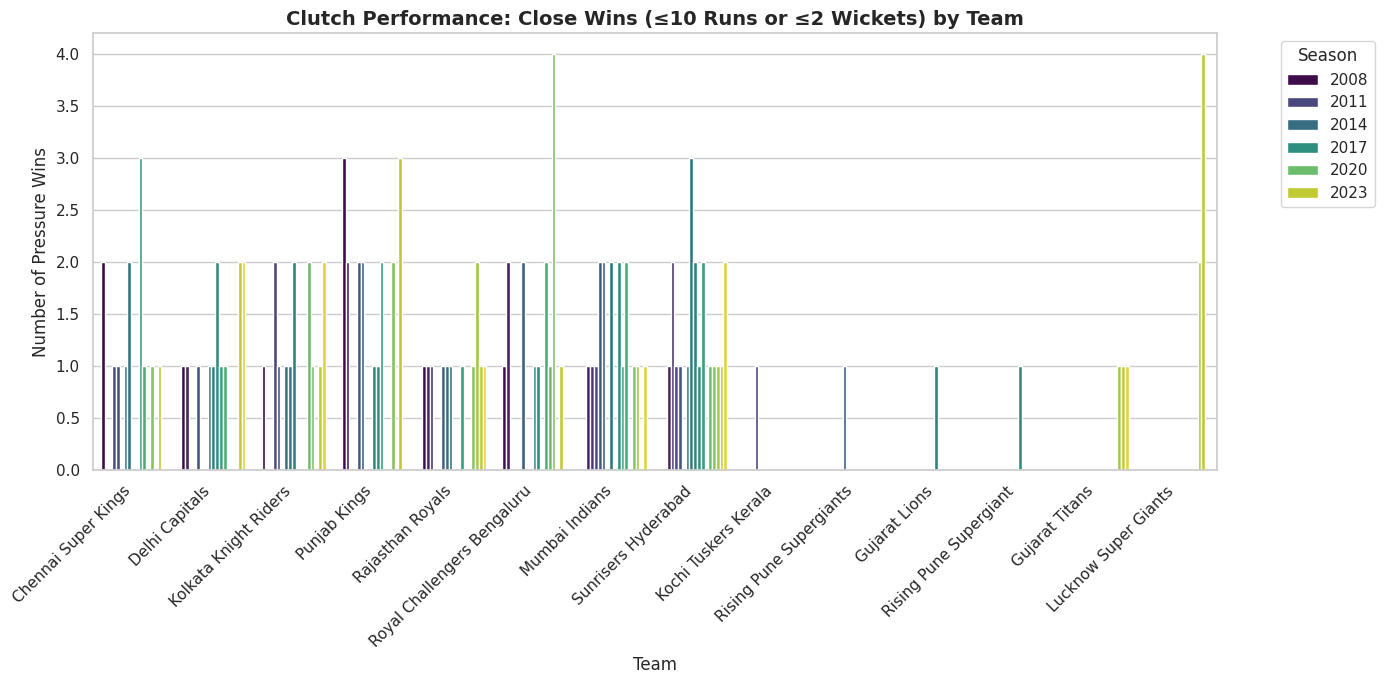

In [ ]:
plt.figure(figsize=(14, 7))

sns.barplot(
    x='winners',
    y='wins',
    hue='season',
    data=pressure,
    palette='viridis'
)

plt.title('Clutch Performance: Close Wins (≤10 Runs or ≤2 Wickets) by Team', fontsize=14, fontweight='bold')
plt.xlabel('Team', fontsize=12)
plt.ylabel('Number of Pressure Wins', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Season', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()